# Speech command recognition from an in-memory audio file (SSR) on FPGA

---

**Authors:** *Mateusz Gibas, Kacper Ferdek*

**Target platform:** ZedBoard (Zynq-7000 XC7Z020) — embedded ARM Cortex-A9 processor (PS) + programmable logic (PL)

**Top module:** `top_ssr` — an AXI4-Lite slave wrapping the recognition core (`top_system`)

---

## Table of contents
1. [Introduction and context](#1-introduction-and-context)
2. [Feature extraction — MFCC](#2-feature-extraction)
3. [Classifier — neural network](#3-classifier)
4. [RTL implementation](#4-rtl-implementation)
5. [Block design (Vivado)](#5-block-design)
6. [Software (main.c)](#6-software)
7. [Testing and results](#7-testing-and-results)
8. [Resource utilisation and timing](#8-resource-utilisation-and-timing)
9. [Summary](#9-summary)

---
## 1. Introduction and context

The goal of this project is a hardware implementation of **single voice-command recognition** (keyword spotting) on an FPGA, operating in **offline** mode: instead of a live microphone-and-ADC stream, the audio signal is **pre-loaded into on-board memory** and processed by a hardware DSP pipeline and a classifier.

In the original version the data source was a microphone via a PMOD AD7991 (I2C). In this version the **ADC and microphone are replaced by an audio file held in memory**, and the whole process is driven by the **embedded ARM processor** (Zynq Processing System) over the **AXI4-Lite** bus. The processor streams the audio samples to the recognition core, which computes the features and the classification, and the processor reads back the result.

Three classes are recognised:

| Output value | Class | Meaning |
|---|---|---|
| `00` | OTHER | command not recognised / other |
| `01` | ON | command "on" (turn the LED on) |
| `10` | OFF | command "off" (turn the LED off) |

The speech signal is sampled at **16 kHz**, 1 s long (16000 samples), represented in **Q1.15** fixed point. Recognition relies not on amplitude but on the **time-frequency content**, so the pipeline computes **MFCC** features (Mel-Frequency Cepstral Coefficients) classified by a small neural network.

Samples: 16000 (~1.00 s),  frames = 1+(N-FRAME)/HOP = 124


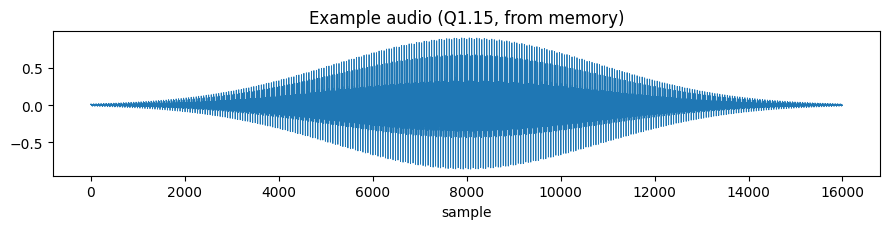

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- pipeline parameters (== ssr_pkg.sv / dsp_fixed.py) ---
SR         = 16000   # sampling rate [Hz]
FRAME_LEN  = 256     # frame length [samples]
HOP_LEN    = 128     # hop between frames
N_FFT      = 256     # DFT size
N_BINS     = 129     # N_FFT/2 + 1
N_MELS     = 26      # mel bands
N_MFCC     = 13      # MFCC coefficients kept
N_FEATURES = 26      # 13 mean + 13 std -> network input
N_SAMPLES  = 16000   # 1 s recording
SAMPLE_W   = 16      # Q1.15

def synth_command(kind='on', dur=1.0, seed=0):
    # Synthetic, noise-free 'voice' so the notebook runs without a recording.
    rng = np.random.default_rng(seed)
    t = np.arange(int(SR*dur))/SR
    formants = {'on':[300,900,1800], 'off':[500,1500,2500], 'other':[400,1200,2000]}[kind]
    env = np.exp(-((t-dur/2)/(dur/4))**2)
    sig = sum(np.sin(2*np.pi*f*t + rng.uniform(0,1)) for f in formants)
    sig = sig/np.max(np.abs(sig)) * env * 0.9
    return sig.astype(np.float32)   # normalised ~Q1.15 range

audio = synth_command('on')
print(f"Samples: {len(audio)} (~{len(audio)/SR:.2f} s),  frames = 1+(N-FRAME)/HOP = {1+(N_SAMPLES-FRAME_LEN)//HOP_LEN}")
plt.figure(figsize=(9,2.4)); plt.plot(audio, lw=0.6)
plt.title("Example audio (Q1.15, from memory)"); plt.xlabel("sample"); plt.tight_layout(); plt.show()

---
## 2. Feature extraction — MFCC

The DSP chain (`dsp_chain`, 8 modules linked by AXI4-Stream) turns the audio into a 26-element feature vector. Stages:

**Framing** — the signal is cut into frames of $N=256$ samples with a hop of $128$ (50% overlap) → 124 frames per 1 s.

**Windowing** — each frame is multiplied by a Hamming window (coefficients in `window_hamming_256.mem`):
$$ w[n] = 0.54 - 0.46\cos\!\Big(\tfrac{2\pi n}{N-1}\Big) $$

**DFT (256-point)** — a fixed-point DFT with precomputed twiddles (`dft_cos_256.mem`, `dft_sin_256.mem`) gives the complex spectrum $X[k]$ (129 bins).

**Power** — $P[k]=\Re^2+\Im^2$.

**Mel filterbank (26 bands)** — power is aggregated into 26 mel bands (`mel_fb_26.mem`):
$$ \text{mel}(f)=2595\log_{10}\!\big(1+\tfrac{f}{700}\big) $$

**Log** — $\log_2$ of the mel energies (`log2` module, with a scale-correction offset).

**DCT (13)** — a discrete cosine transform (`dct_13x26.mem`) of the 26 log-mel values keeps the first 13 coefficients → MFCC per frame.

**Aggregator** — over all frames it computes the **mean and standard deviation of each of the 13 MFCCs**, giving the final **26-element feature vector (13 mean + 13 std)** fed to the network.

The entire chain is **fixed-point** (no floating point); the formats are defined in `ssr_pkg.sv`. The Python model below mirrors the maths for verification.

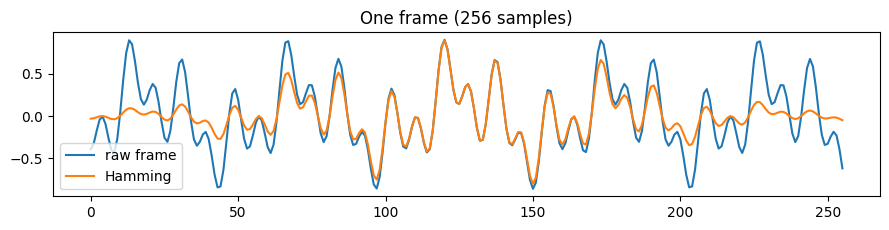

frames: 124


In [2]:
def hamming(N): n=np.arange(N); return 0.54-0.46*np.cos(2*np.pi*n/(N-1))
def frame_sig(x,N,H):
    nf=1+(len(x)-N)//H
    return np.stack([x[i*H:i*H+N] for i in range(nf)])

W=hamming(FRAME_LEN)
F=frame_sig(audio,FRAME_LEN,HOP_LEN)
Fw=F*W
plt.figure(figsize=(9,2.4))
plt.plot(F[len(F)//2],label='raw frame'); plt.plot(Fw[len(F)//2],label='Hamming')
plt.title("One frame (256 samples)"); plt.legend(); plt.tight_layout(); plt.show()
print("frames:",F.shape[0])

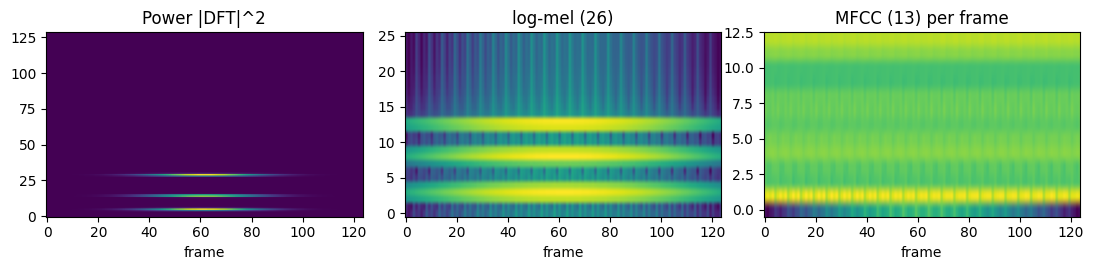

In [3]:
def mel_fb(n_fft,fs,n_mel):
    mel=lambda f:2595*np.log10(1+f/700); imel=lambda m:700*(10**(m/2595)-1)
    pts=imel(np.linspace(mel(0),mel(fs/2),n_mel+2)); b=np.floor((n_fft+1)*pts/fs).astype(int)
    fb=np.zeros((n_mel,n_fft//2+1))
    for m in range(1,n_mel+1):
        l,c,r=b[m-1],b[m],b[m+1]
        for k in range(l,c): fb[m-1,k]=(k-l)/max(1,c-l)
        for k in range(c,r): fb[m-1,k]=(r-k)/max(1,r-c)
    return fb
def dct_mat(n_mfcc,n_mel):
    M=np.zeros((n_mfcc,n_mel))
    for i in range(n_mfcc):
        for j in range(n_mel): M[i,j]=np.cos(np.pi*i*(2*j+1)/(2*n_mel))
    return M

FB=mel_fb(N_FFT,SR,N_MELS); D=dct_mat(N_MFCC,N_MELS)
P=np.abs(np.fft.rfft(Fw,axis=1))**2          # power
Mel=P@FB.T                                   # 26 mel energies / frame
LogMel=np.log2(Mel+1e-6)                      # log
MFCC=LogMel@D.T                               # 13 MFCC / frame
fig,ax=plt.subplots(1,3,figsize=(11,2.8))
ax[0].imshow(P.T,aspect='auto',origin='lower');   ax[0].set_title("Power |DFT|^2")
ax[1].imshow(LogMel.T,aspect='auto',origin='lower');ax[1].set_title("log-mel (26)")
ax[2].imshow(MFCC.T,aspect='auto',origin='lower'); ax[2].set_title("MFCC (13) per frame")
for a in ax: a.set_xlabel("frame")
plt.tight_layout(); plt.show()

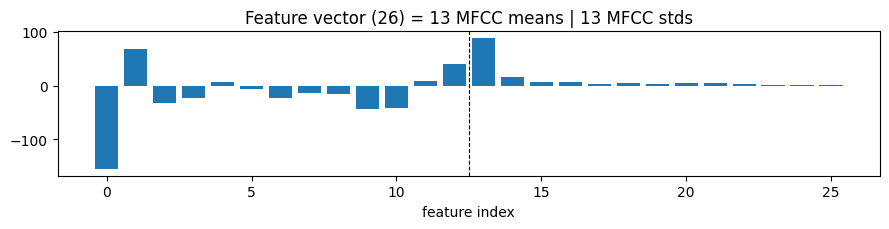

feature vector length: 26


In [4]:
# Aggregator: mean + std of each MFCC over frames -> 26-element feature vector
feat = np.concatenate([MFCC.mean(axis=0), MFCC.std(axis=0)])   # 13 + 13
plt.figure(figsize=(9,2.4)); plt.bar(range(N_FEATURES),feat)
plt.axvline(12.5,color='k',ls='--',lw=0.8)
plt.title("Feature vector (26) = 13 MFCC means | 13 MFCC stds"); plt.xlabel("feature index")
plt.tight_layout(); plt.show()
print("feature vector length:",len(feat))

---
## 3. Classifier — neural network

The 26-element vector is classified by a small fully-connected network in SystemVerilog (`top_nn`), fixed-point:

| Layer | In | Out | Notes |
|---|---|---|---|
| `dense_layer_1` | 26 | hidden | + activation |
| `dense_layer_2` | hidden | 3 | logits |
| `final_layer` | 3 | 2 bits | argmax → command |

`final_layer` encoding (from the RTL):

$$ \text{out}=\begin{cases} 01\ (\text{ON})  & l_0>l_1 \wedge l_0>l_2\\ 10\ (\text{OFF}) & l_1>l_0 \wedge l_1>l_2\\ 00\ (\text{OTHER}) & \text{otherwise}\end{cases} $$

`top_nn` exposes `done1_out`/`done2_out`; `top_system` uses `done2` to know the result is ready (`output_valid`). The weights were trained in Python and exported to the RTL.

---
## 4. RTL implementation

The **top module is `top_ssr`** — an **AXI4-Lite slave** that wraps the recognition core `top_system`. The processor talks only to `top_ssr`; the audio stream and the result handshake are handled inside.

### 4.1 `top_ssr` register map (AXI4-Lite)

| Offset | Name | Access | Description |
|---|---|---|---|
| `0x00` | CTRL | W | bit0 `soft_reset` (resets the whole core) |
| `0x04` | N_SAMPLES | W | number of samples in the recording (for `s_tlast`) |
| `0x08` | SAMPLE | W | `[15:0]` Q1.15 sample; each write = one AXI-Stream beat |
| `0x0C` | STATUS | R | bit0 `ready`, bit1 `output_valid`, bit2 `busy` |
| `0x10` | RESULT | R | `[1:0]` result (0=other, 1=on, 2=off) |

On a `SAMPLE` write, `top_ssr` drives one beat of the core's AXI-Stream input (`s_tdata/valid/last`), handling `s_tready` back-pressure and asserting `s_tlast` on the last of `N_SAMPLES`. The classification result (`output_value`) and flags are exposed through `STATUS`/`RESULT`, and an `led0` output is driven directly (on→1, off→0).

### 4.2 Core `top_system`

`top_system` chains: **`dsp_chain` → `feature_buffer` (FSM) → `top_nn`**. `dsp_chain` emits the 26 features sequentially as AXI-Stream (with `tuser` = feature id 0..25); the `feature_buffer` FSM collects them into a parallel vector and then releases the network reset to start `top_nn`; `output_valid` rises when `done2` arrives.

### 4.3 `dsp_chain` modules (AXI4-Stream)

`framing → window → dft → power → mel → log2 → dct → aggregator`. Coefficient tables are stored in `.mem` files: `window_hamming_256.mem`, `dft_cos_256.mem`, `dft_sin_256.mem`, `mel_fb_26.mem`, `dct_13x26.mem`.

### 4.4 ZedBoard architecture (data flow)

```
   ARM (PS) ──AXI4-Lite──► top_ssr ──(AXI-Stream)──► top_system (dsp_chain → top_nn) ──► output_value, led0
      ▲   reads STATUS/RESULT
      │
   AXI GPIO ◄── 5 push-buttons (choose which file to send)
```

---
## 5. Block design (Vivado)

The system was assembled in Vivado IP Integrator on the ZedBoard preset. The processor (**ZYNQ7 Processing System**) drives, through an **AXI Interconnect**, two slaves: the **AXI GPIO** (push-buttons) and the packaged recognition core **`top_ssr`** (here `top_ssr_v1_0`, with its `s00_axi` slave port and `led0` output). A **Processor System Reset** synchronises the reset to the PL fabric clock (≈ 50 MHz, hence `rst_ps7_0_50M`). `DDR` and `FIXED_IO` are external PS interfaces from the board preset.

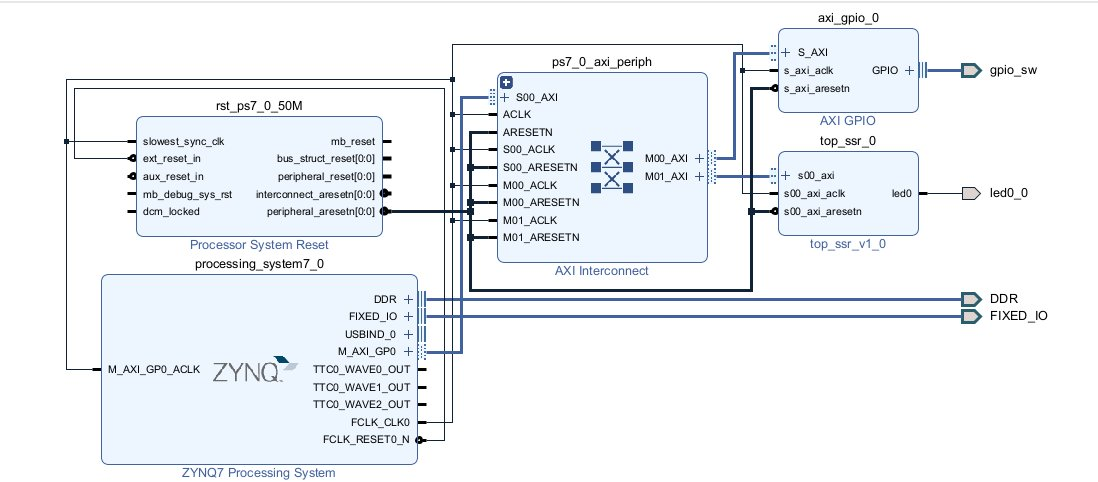

*Fig. — Block design: ZYNQ7 PS + AXI Interconnect + AXI GPIO + `top_ssr` core, with the `led0` output made external.*

---
## 6. Software (`main.c`)

The application running on the ARM (`project_final/main.c`) is **button-driven**. Each of the five ZedBoard push-buttons (read through an **AXI GPIO**) sends a different audio file (held in `audio_files.h` as Q1.15 arrays) to the core:

`BTNC → ON(good), BTNU → OFF(good), BTND → OTHER(good), BTNL → ON(bad), BTNR → OTHER(bad)`.

On a button press the program: (1) soft-resets the core (`CTRL`), (2) writes `N_SAMPLES`, (3) streams every sample to `SAMPLE` while polling `STATUS.ready`, (4) waits for `STATUS.output_valid`, (5) reads `RESULT` and prints it over UART (the LED is driven in hardware). A short debounce and a release-wait guard against bouncing. Because the program runs from the PS DDR, all audio files fit comfortably in memory.

Simplified loop:

```c
for (;;) {
    pressed = read_buttons_edge();
    if (pressed) {
        process_file(&audio_files[btn_to_file[b]]);  // reset, N_SAMPLES, stream, read RESULT
        wait_release();
    }
}
```

---
## 7. Testing and results

Verification at three levels: (1) the Python MFCC model above, (2) RTL simulation in xsim, (3) hardware on the ZedBoard (button → result over UART, LED reacts).

### 7.1 Neural-network simulation (`top_nn_tb.sv`)

Feature vectors extracted from real "good" and "bad" recordings were fed into the network in simulation. Transcribed result (`output_value`: 0=other, 1=on, 2=off):

| Input recording | NN output | Expected | Correct |
|---|:---:|:---:|:---:|
| ON_BAD   | 2 (off)   | 1 (on)  | ✗ |
| ON_GOOD  | 1 (on)    | 1 (on)  | ✓ |
| ON_BAD   | 0 (other) | 1 (on)  | ✗ |
| OFF_BAD  | 1 (on)    | 2 (off) | ✗ |
| OFF_GOOD | 2 (off)   | 2 (off) | ✓ |
| OTH_GOOD | 0 (other) | 0 (other) | ✓ |
| OTH_BAD  | 1 (on)    | 0 (other) | ✗ |

**Observation.** All three **clean ("good") recordings are classified correctly** (ON_GOOD→on, OFF_GOOD→off, OTH_GOOD→other). The **degraded ("bad") recordings are misclassified**. This matches expectations for a small network trained on clean speech: it generalises to clean inputs but is sensitive to noise / poor articulation, which shift the MFCC distribution away from the training data.

### 7.2 Hardware results

To be completed after running on the ZedBoard (button → UART line `-> wynik = X (ON/OFF/OTHER)`, LED state).

In [5]:
import pandas as pd
nn_results = [
    ("ON_BAD",  2, 1), ("ON_GOOD", 1, 1), ("ON_BAD", 0, 1),
    ("OFF_BAD", 1, 2), ("OFF_GOOD",2, 2),
    ("OTH_GOOD",0, 0), ("OTH_BAD", 1, 0),
]
lab={0:"other",1:"on",2:"off"}
rows=[{"Recording":r,"NN output":f"{g} ({lab[g]})","Expected":f"{e} ({lab[e]})",
       "Correct":"YES" if g==e else "no"} for r,g,e in nn_results]
df=pd.DataFrame(rows)
acc=sum(1 for _,g,e in nn_results if g==e)/len(nn_results)
print(f"Overall accuracy on this set: {acc*100:.0f}%  (good recordings: 3/3 correct)")
df

Overall accuracy on this set: 43%  (good recordings: 3/3 correct)


,Recording,NN output,Expected,Correct
0,ON_BAD,2 (off),1 (on),no
1,ON_GOOD,1 (on),1 (on),YES
2,ON_BAD,0 (other),1 (on),no
3,OFF_BAD,1 (on),2 (off),no
4,OFF_GOOD,2 (off),2 (off),YES
5,OTH_GOOD,0 (other),0 (other),YES
6,OTH_BAD,1 (on),0 (other),no


---
## 8. Resource utilisation and timing

After place & route on the XC7Z020 (ZedBoard) the design uses the following resources:

| Resource | Used | Available | Utilisation |
|---|---:|---:|---:|
| LUT  | 28 905 | 53 200 | ~54% |
| FF   | 19 524 | 106 400 | ~18% |
| DSP  | 86 | 220 | ~39% |
| BRAM | 0.5 | 140 | <1% |

The DSP usage (86 blocks) and LUT count are consistent with a datapath containing a 256-point DFT and the multiply-accumulate operations of the neural network. The design fits comfortably on the device with ample margin.

**Timing.** After place & route the design **meets all timing constraints** at the chosen PL fabric clock (~50 MHz): the worst negative slack (WNS) is non-negative, so there are no setup/hold violations and the design is safe to run on hardware.


---
## 9. Summary

The project implements hardware voice-command recognition operating **from an audio file in memory**, controlled by the **embedded ARM processor** on the ZedBoard over **AXI4-Lite**. The top module `top_ssr` wraps the recognition core `top_system` (full MFCC front-end + a small neural network) and exposes a simple register interface; the processor streams the samples and reads the result, while five push-buttons select which recording to test.

The whole DSP + NN datapath runs in **fixed-point arithmetic** — a deliberate choice that keeps the logic compact and timing-friendly at the cost of rounding error that adds to the MFCC approximation.

**Result (honest assessment).** In simulation the network **correctly classifies clean recordings** (ON_GOOD→on, OFF_GOOD→off, OTHER_GOOD→other), and **misclassifies degraded recordings**. So the full chain — audio in memory → processor → AXI4-Lite → MFCC → network → result/LED — works end-to-end, and the recognition is correct for in-distribution (clean) speech. Robustness to noisy / poorly-articulated input would require training the network on a wider, augmented dataset (and re-exporting the weights to the RTL).

### References
- AMD/Xilinx: Zynq-7000 TRM (UG585), AXI Reference Guide (UG1037).
- Davis & Mermelstein, *MFCC for monosyllabic word recognition*, 1980.
- Project repository: github.com/H1tchie/simple_speech_recognition